In [1]:
!pip install kaggle

In [2]:
#configuring the path of kaggle.json file
!mkdir -p ~/.kaggle
!cp '/content/kaggle .json' ~/.kaggle/
!chmod 600 ~/.kaggle/'kaggle .json'

cp: cannot stat '/content/kaggle .json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle .json': No such file or directory


In [3]:
# Rename the kaggle.json file to remove the space, as expected by the Kaggle CLI
!mv ~/.kaggle/'kaggle .json' ~/.kaggle/kaggle.json

mv: cannot stat '/root/.kaggle/kaggle .json': No such file or directory


In [4]:
# Now try to download the dataset again
!kaggle datasets download -d wordroid/cifar10-object-recognition-in-images-zip-file

Dataset URL: https://www.kaggle.com/datasets/wordroid/cifar10-object-recognition-in-images-zip-file
License(s): unknown
100% 1.54G/1.54G [00:13<00:00, 123MB/s]



In [5]:
!ls

cifar10-object-recognition-in-images-zip-file.zip  sample_data


In [6]:
import zipfile
zip_ref=zipfile.ZipFile('/content/cifar10-object-recognition-in-images-zip-file.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [7]:
#!unzip /content/cifar10-object-recognition-in-images-zip-file.zip

In [8]:
#!pip install py7zr

In [9]:
'''import py7zr
new=py7zr.SevenZipFile('/content/train_test.7z',mode='r')
new.extractall()
new.close()'''

#import library


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

In [10]:
#chk the list of train dataset
filenames=os.listdir('/content/train_test')

type(filenames)

len(filenames)

print(filenames[0:5])

['test', 'train', 'test.zip', 'train.zip']


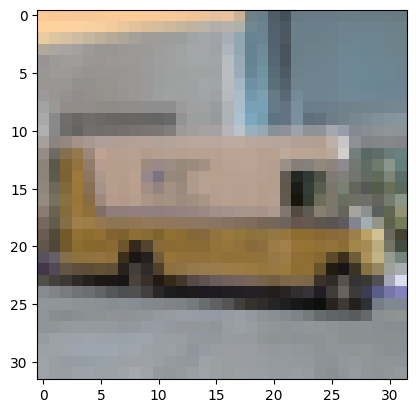

In [11]:
#*Label* *Processing*

import pandas as pd
label_df=pd.read_csv('/content/trainLabels.csv')

label_df.shape

label_df.head(5)

label_df.tail(5)

label_df['label']

label_df['label'].unique()

label_df['label'].value_counts()

label_df['label'].value_counts()

label_dict={'frog':0, 'truck':1, 'deer':2, 'automobile':3, 'bird':4, 'horse':5, 'ship':6,
       'cat':7, 'dog':8, 'airplane':9}
labels=label_df['label'].map(label_dict)
labels

labels[0:5]

import cv2
img=cv2.imread('/content/train_test/train/train/9894.png')
plt.imshow(img)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
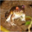

In [12]:
# convert images to numpy arrays
from PIL import Image
id_list = list(label_df['id'])
train_data_folder = '/content/train_test/train/train/'

data = []

for id in id_list:

  image = Image.open(train_data_folder + str(id) + '.png')
  image = np.array(image)
  data.append(image)

type(data)

len(data)

data[0].shape

data[0]

In [13]:
#converting image and list into numpy array
x=np.array(data)
y=np.array(labels)

x.shape

y.shape

#train test and split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
#scaling the data
x_train=x_train/255
x_test=x_test/255

print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

x_train[0]

(40000, 32, 32, 3) (40000,)
(10000, 32, 32, 3) (10000,)


array([[[0.13333333, 0.14117647, 0.16862745],
        [0.14509804, 0.14509804, 0.2       ],
        [0.17254902, 0.17254902, 0.25098039],
        ...,
        [0.24313725, 0.28627451, 0.36470588],
        [0.20392157, 0.24705882, 0.3254902 ],
        [0.17647059, 0.22352941, 0.30196078]],

       [[0.1372549 , 0.1372549 , 0.14509804],
        [0.13333333, 0.13333333, 0.15686275],
        [0.13333333, 0.12941176, 0.16862745],
        ...,
        [0.22745098, 0.27058824, 0.34901961],
        [0.19607843, 0.23529412, 0.31372549],
        [0.18431373, 0.22745098, 0.30588235]],

       [[0.13333333, 0.12941176, 0.1372549 ],
        [0.12941176, 0.1254902 , 0.14117647],
        [0.12941176, 0.1254902 , 0.14901961],
        ...,
        [0.25882353, 0.30196078, 0.38039216],
        [0.2       , 0.24313725, 0.32156863],
        [0.20784314, 0.25098039, 0.32941176]],

       ...,

       [[0.1254902 , 0.1254902 , 0.14901961],
        [0.1254902 , 0.12156863, 0.14509804],
        [0.12941176, 0

In [15]:
#*Building the Neural Network*

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,BatchNormalization,Dropout
#from keras import Sequential
#rom keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

#Train a neural network

model=Sequential([
    Flatten(input_shape=(32,32,3)),
    Dense(128,activation='relu'),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')


])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model.fit(x_train,y_train,epochs=10,validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3204 - loss: 1.8831 - val_accuracy: 0.3837 - val_loss: 1.7292
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3835 - loss: 1.7165 - val_accuracy: 0.3910 - val_loss: 1.6866
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4088 - loss: 1.6468 - val_accuracy: 0.4145 - val_loss: 1.6479
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4201 - loss: 1.6098 - val_accuracy: 0.4205 - val_loss: 1.6168
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4398 - loss: 1.5699 - val_accuracy: 0.4025 - val_loss: 1.6486
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4431 - loss: 1.5521 - val_accuracy: 0.4395 - val_loss: 1.5651
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4506 - loss: 1.5325 - val_accuracy: 0.4450 - val_loss: 1.5518
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4604 - loss: 1.5075 - 

In [16]:
#*Resnet50*

from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import Dropout,Flatten,BatchNormalization,Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers


convolution_base=ResNet50(weights='imagenet',include_top=False,input_shape=(256,256,3))
convolution_base.summary()

num_of_class=10
model=Sequential()
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(convolution_base)
model.add(layers.Flatten())
model.add(layers.BatchNormalization())
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(10,activation='sigmoid'))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [17]:
from tensorflow.keras import optimizers
model.compile(optimizer=optimizers.RMSprop(learning_rate=2e-5),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,epochs=5,validation_split=0.1)

Epoch 1/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 485s 384ms/step - accuracy: 0.4441 - loss: 1.6724 - val_accuracy: 0.7538 - val_loss: 0.9343
Epoch 2/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 432s 384ms/step - accuracy: 0.6965 - loss: 1.0188 - val_accuracy: 0.8810 - val_loss: 0.4796
Epoch 3/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 433s 384ms/step - accuracy: 0.8027 - loss: 0.7448 - val_accuracy: 0.9145 - val_loss: 0.3558
Epoch 4/5
  99/1125 ━━━━━━━━━━━━━━━━━━━━ 6:21 372ms/step - accuracy: 0.8471 - loss: 0.6211

In [ ]:
accuracy,loss=model.evaluate(x_test,y_test)

In [ ]:
#plot loss vlaue
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [ ]:
#plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

In [ ]:
model.save('cifar10-object-recognition.keras')

In [ ]:
from google.colab import files
files.download('cifar10-object-recognition.keras')